In [1]:
#required packages
import sys
import os
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sb
import random as rd
import warnings
import tqdm
from tqdm import tqdm
import tabulate

import sklearn
from sklearn.decomposition import PCA
from google.colab import drive
from google.colab import files

#mount to gdrive
drive.mount('/content/gdrive')
gdrive_path = '/content/gdrive/MyDrive/REVEAL_UCSF_project/chemical_database_list'
gdrive_path2 = '/content/gdrive/MyDrive/REVEAL_UCSF_project/First400'
gdrive_path4 = '/content/gdrive/MyDrive/REVEAL_UCSF_project/chemical_database_list'
#path to local directory


Mounted at /content/gdrive


In [2]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 46.8 MB/s eta 0:00:00


In [3]:
#install isospcpy
!pip install IsoSpecPy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.1/152.1 kB 5.7 MB/s eta 0:00:00


In [4]:
# Function to calculate ppm difference
def ppm_difference(value1, value2):
    return abs(value1 - value2) / value1 * 1e6


In [5]:
from tqdm import tqdm
import tabulate
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors
peakarea_path = [os.path.join(gdrive_path2, "pos_Area_1_2025_06_12_14_43_23_updated.csv")]
QACs_path = [os.path.join(gdrive_path2,'QACs_chemical_list_comptox_March09_updated.csv')]
QACs_path2 = [os.path.join(gdrive_path,'8QACs_chemical_list_comptox_with_istd_April19.csv')]  #with ISTD: D15-TPP

#load peak area
pos_peak_area = pd.read_csv(peakarea_path[0])
QACs_mz = pd.read_csv(QACs_path[0])
print(pos_peak_area.shape)
print(QACs_mz.shape)

(64004, 967)
(49, 16)



ISTD target table:
+-------------+------------+--------------+--------+
| Compound    | Category   |   Exact_mass |     RT |
|-------------+------------+--------------+--------|
| DL-Cotinine | ISTD       |      180.121 |  3.478 |
| TPP-D15     | ISTD       |      342.172 | 11.74  |
+-------------+------------+--------------+--------+

DL-Cotinine: matched candidate rows = 8
+-------------+--------------+-------------------+-------------+-------------+-----------------+
| Compound    |   Average Mz |   Average Rt(min) |   Target_mz |   Target_RT | feature_id      |
|-------------+--------------+-------------------+-------------+-------------+-----------------|
| DL-Cotinine |      180.121 |             3.94  |     180.121 |       3.478 | 180.12083_3.94  |
| DL-Cotinine |      180.121 |             3.161 |     180.121 |       3.478 | 180.12109_3.161 |
| DL-Cotinine |      180.121 |             3.287 |     180.121 |       3.478 | 180.12129_3.287 |
| DL-Cotinine |      180.121 |         

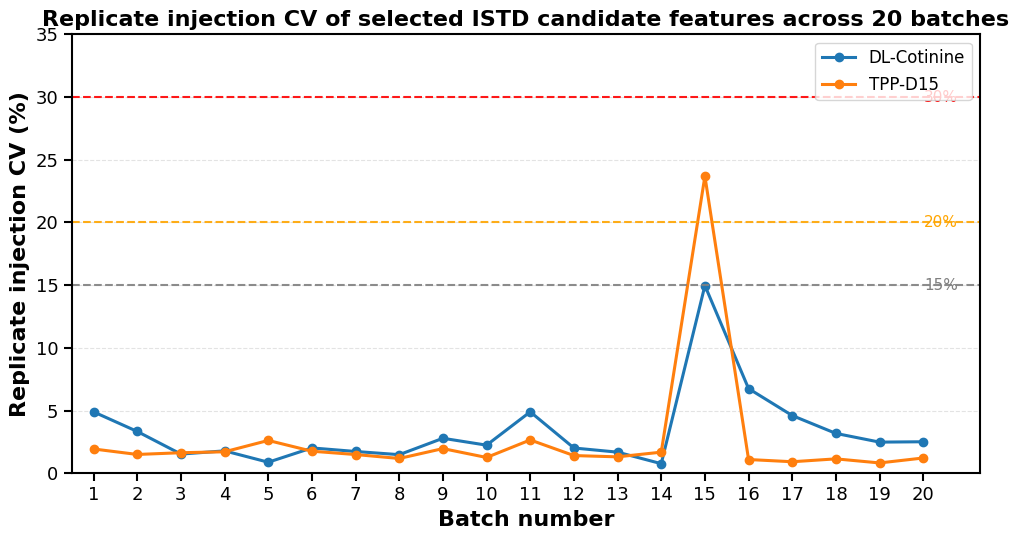

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tabulate
from tqdm import tqdm

# ==========================================================
# 0) Helper function
# ==========================================================

def ppm_difference(observed_mz, theoretical_mz):
    return abs(observed_mz - theoretical_mz) / theoretical_mz * 1e6


# ==========================================================
# 1) Define ISTD targets
# ==========================================================

ISTD_targets = pd.DataFrame({
    "Compound": [
        "DL-Cotinine",
        "TPP-D15"
    ],
    "Category": [
        "ISTD",
        "ISTD"
    ],
    "Exact_mass": [
        180.1211,
        342.1722
    ],
    "RT": [
        3.478,
        11.74
    ]
})

ppm_threshold = 10
RT_threshold = 0.5

print("\nISTD target table:")
print(tabulate.tabulate(
    ISTD_targets,
    headers="keys",
    tablefmt="psql",
    showindex=False
))


# ==========================================================
# 2) Function: exact mass + RT search + CV calculation
# ==========================================================

def extract_istd_cv(
    peak_table,
    target_mz,
    target_rt,
    compound_name,
    ppm_threshold=10,
    rt_threshold=0.5,
    batch_size=20
):

    peak_table = peak_table.copy()

    peak_table["Average Mz"] = pd.to_numeric(
        peak_table["Average Mz"],
        errors="coerce"
    )

    peak_table["Average Rt(min)"] = pd.to_numeric(
        peak_table["Average Rt(min)"],
        errors="coerce"
    )

    # ======================================================
    # Exact mass + RT matching
    # ======================================================

    matches = peak_table[
        peak_table["Average Mz"].apply(
            lambda mz: ppm_difference(mz, target_mz) <= ppm_threshold
            if pd.notna(mz) else False
        )
    ].copy()

    matches = matches[
        matches["Average Rt(min)"].apply(
            lambda rt: abs(rt - target_rt) <= rt_threshold
            if pd.notna(rt) else False
        )
    ].copy()

    if matches.empty:
        raise ValueError(
            f"No matched candidate rows found for {compound_name}. "
            f"Check m/z, RT, ppm threshold, and RT threshold."
        )

    matches["Compound"] = compound_name
    matches["Target_mz"] = target_mz
    matches["Target_RT"] = target_rt
    matches["DTXSID"] = compound_name
    matches["feature_id"] = (
        matches["Average Mz"].astype(str)
        + "_"
        + matches["Average Rt(min)"].astype(str)
    )

    print(f"\n{compound_name}: matched candidate rows = {matches.shape[0]}")
    print(tabulate.tabulate(
        matches[
            [
                "Compound",
                "Average Mz",
                "Average Rt(min)",
                "Target_mz",
                "Target_RT",
                "feature_id"
            ]
        ],
        headers="keys",
        tablefmt="psql",
        showindex=False
    ))

    # ======================================================
    # Identify BH replicate columns
    # ======================================================

    bh_columns = [
        col for col in matches.columns
        if str(col).startswith("BH")
    ]

    if len(bh_columns) == 0:
        raise ValueError(f"No BH columns found for {compound_name}.")

    grouped_samples = {}

    for col in bh_columns:
        sample_id = str(col).split("_")[0].strip()
        grouped_samples.setdefault(sample_id, []).append(col)

    sample_ids = list(grouped_samples.keys())

    print(f"{compound_name}: raw BH replicate columns = {len(bh_columns)}")
    print(f"{compound_name}: unique samples = {len(sample_ids)}")

    # Convert replicate columns to numeric
    for col in bh_columns:
        matches[col] = pd.to_numeric(
            matches[col],
            errors="coerce"
        )

    # ======================================================
    # Candidate row-level mean, SD, CV%, Nrep for each sample
    # ======================================================

    mean_columns = {}
    sd_columns = {}
    cv_columns = {}
    nrep_columns = {}

    for sample_id, replicate_cols in grouped_samples.items():

        replicate_data = matches[replicate_cols]

        mean_values = replicate_data.mean(axis=1, skipna=True)
        sd_values = replicate_data.std(axis=1, skipna=True, ddof=1)
        nrep_values = replicate_data.notna().sum(axis=1)

        cv_values = np.where(
            (mean_values > 0) & (nrep_values >= 2),
            sd_values / mean_values * 100,
            np.nan
        )

        mean_columns[sample_id] = mean_values
        sd_columns[sample_id + "_SD"] = sd_values
        cv_columns[sample_id + "_CV_percent"] = cv_values
        nrep_columns[sample_id + "_Nrep"] = nrep_values

    mean_columns_df = pd.DataFrame(mean_columns, index=matches.index)
    sd_columns_df = pd.DataFrame(sd_columns, index=matches.index)
    cv_columns_df = pd.DataFrame(cv_columns, index=matches.index)
    nrep_columns_df = pd.DataFrame(nrep_columns, index=matches.index)

    candidate_table = matches.drop(columns=bh_columns).copy()

    candidate_table = pd.concat(
        [
            candidate_table,
            mean_columns_df,
            sd_columns_df,
            cv_columns_df,
            nrep_columns_df
        ],
        axis=1
    )

    # ======================================================
    # Per-sample ranking across candidate rows
    # Select candidate row with maximum mean peak area
    # Then extract the CV% from the same row
    # ======================================================

    peak_record = {"Compound": compound_name}
    cv_record = {"Compound": compound_name}
    sd_record = {"Compound": compound_name}
    nrep_record = {"Compound": compound_name}
    feature_record = {"Compound": compound_name}
    mz_record = {"Compound": compound_name}
    rt_record = {"Compound": compound_name}

    sample_cv_records = []

    for sample_id in sample_ids:

        mean_col = sample_id
        sd_col = sample_id + "_SD"
        cv_col = sample_id + "_CV_percent"
        nrep_col = sample_id + "_Nrep"

        sample_mean_values = pd.to_numeric(
            candidate_table[mean_col],
            errors="coerce"
        )

        if sample_mean_values.notna().any():

            best_idx = sample_mean_values.idxmax()
            best_row = candidate_table.loc[best_idx]

            selected_mean_peak = best_row[mean_col]
            selected_sd = best_row[sd_col]
            selected_cv = best_row[cv_col]
            selected_nrep = best_row[nrep_col]
            selected_feature_id = best_row["feature_id"]
            selected_mz = best_row["Average Mz"]
            selected_rt = best_row["Average Rt(min)"]

        else:
            selected_mean_peak = np.nan
            selected_sd = np.nan
            selected_cv = np.nan
            selected_nrep = np.nan
            selected_feature_id = np.nan
            selected_mz = np.nan
            selected_rt = np.nan

        peak_record[sample_id] = selected_mean_peak
        cv_record[sample_id + "_CV_percent"] = selected_cv
        sd_record[sample_id + "_SD"] = selected_sd
        nrep_record[sample_id + "_Nrep"] = selected_nrep
        feature_record[sample_id + "_selected_feature_id"] = selected_feature_id
        mz_record[sample_id + "_selected_mz"] = selected_mz
        rt_record[sample_id + "_selected_rt"] = selected_rt

        sample_cv_records.append({
            "Compound": compound_name,
            "Sample_ID": sample_id,
            "Selected_mean_peak_area": selected_mean_peak,
            "Selected_SD": selected_sd,
            "ISTD_replicate_CV_percent": selected_cv,
            "N_replicates": selected_nrep,
            "Selected_feature_id": selected_feature_id,
            "Selected_mz": selected_mz,
            "Selected_rt": selected_rt
        })

    selected_peak_table = pd.DataFrame([peak_record])
    selected_cv_table = pd.DataFrame([cv_record])
    selected_sd_table = pd.DataFrame([sd_record])
    selected_nrep_table = pd.DataFrame([nrep_record])
    selected_feature_table = pd.DataFrame([feature_record])
    selected_mz_table = pd.DataFrame([mz_record])
    selected_rt_table = pd.DataFrame([rt_record])

    sample_cv_df = pd.DataFrame(sample_cv_records)

    sample_cv_df = sample_cv_df.sort_values(
        "Sample_ID"
    ).reset_index(drop=True)

    sample_cv_df["Batch"] = (
        np.arange(sample_cv_df.shape[0]) // batch_size
    ) + 1

    batch_cv_summary = (
        sample_cv_df
        .groupby(["Compound", "Batch"])
        .agg(
            N_samples=("Sample_ID", "count"),
            Mean_CV_percent=("ISTD_replicate_CV_percent", "mean"),
            Median_CV_percent=("ISTD_replicate_CV_percent", "median"),
            SD_CV_percent=("ISTD_replicate_CV_percent", "std"),
            Min_CV_percent=("ISTD_replicate_CV_percent", "min"),
            Max_CV_percent=("ISTD_replicate_CV_percent", "max"),
            Mean_peak_area=("Selected_mean_peak_area", "mean"),
            Median_peak_area=("Selected_mean_peak_area", "median")
        )
        .reset_index()
    )

    return {
        "candidate_table": candidate_table,
        "selected_peak_table": selected_peak_table,
        "selected_cv_table": selected_cv_table,
        "selected_sd_table": selected_sd_table,
        "selected_nrep_table": selected_nrep_table,
        "selected_feature_table": selected_feature_table,
        "selected_mz_table": selected_mz_table,
        "selected_rt_table": selected_rt_table,
        "sample_cv_df": sample_cv_df,
        "batch_cv_summary": batch_cv_summary,
        "grouped_samples": grouped_samples,
        "raw_candidate_matches": matches
    }


# ==========================================================
# 3) Run extraction for both ISTDs
# ==========================================================

all_results = {}

for _, row in ISTD_targets.iterrows():

    compound_name = row["Compound"]

    result = extract_istd_cv(
        peak_table=pos_peak_area,
        target_mz=row["Exact_mass"],
        target_rt=row["RT"],
        compound_name=compound_name,
        ppm_threshold=ppm_threshold,
        rt_threshold=RT_threshold,
        batch_size=20
    )

    all_results[compound_name] = result


# ==========================================================
# 4) Combine outputs
# ==========================================================

all_candidate_table = pd.concat(
    [res["candidate_table"] for res in all_results.values()],
    ignore_index=True
)

all_sample_cv_df = pd.concat(
    [res["sample_cv_df"] for res in all_results.values()],
    ignore_index=True
)

all_batch_cv_summary = pd.concat(
    [res["batch_cv_summary"] for res in all_results.values()],
    ignore_index=True
)

all_selected_peak_table = pd.concat(
    [res["selected_peak_table"] for res in all_results.values()],
    ignore_index=True
)

all_selected_cv_table = pd.concat(
    [res["selected_cv_table"] for res in all_results.values()],
    ignore_index=True
)

all_selected_feature_table = pd.concat(
    [res["selected_feature_table"] for res in all_results.values()],
    ignore_index=True
)

print("\nCombined sample-level CV preview:")
print(tabulate.tabulate(
    all_sample_cv_df.head(20),
    headers="keys",
    tablefmt="psql",
    showindex=False
))

print("\nCombined batch-level CV summary:")
print(tabulate.tabulate(
    all_batch_cv_summary,
    headers="keys",
    tablefmt="psql",
    showindex=False
))

# Save tables
all_candidate_table.to_csv(
    "ISTD_candidate_table_mean_CV_all_rows.csv",
    index=False
)

all_sample_cv_df.to_csv(
    "ISTD_sample_selected_candidate_CV_percent.csv",
    index=False
)

all_batch_cv_summary.to_csv(
    "ISTD_batch_selected_candidate_CV_summary.csv",
    index=False
)

all_selected_peak_table.to_csv(
    "ISTD_selected_max_mean_peak_area.csv",
    index=False
)

all_selected_cv_table.to_csv(
    "ISTD_selected_corresponding_CV_percent.csv",
    index=False
)

all_selected_feature_table.to_csv(
    "ISTD_selected_feature_per_sample.csv",
    index=False
)


# ==========================================================
# Plot both ISTDs across 20 batches
# ==========================================================

fig, ax = plt.subplots(figsize=(10, 5.5))

for compound in ISTD_targets["Compound"]:

    tmp = all_batch_cv_summary[
        all_batch_cv_summary["Compound"] == compound
    ].copy()

    ax.plot(
        tmp["Batch"],
        tmp["Mean_CV_percent"],
        marker="o",
        markersize=6,
        linewidth=2.2,
        label=compound
    )

    # ax.fill_between(
    #     tmp["Batch"],
    #     tmp["Mean_CV_percent"] - tmp["SD_CV_percent"],
    #     tmp["Mean_CV_percent"] + tmp["SD_CV_percent"],
    #     alpha=0.15
    # )

# Reference lines
for y_value, label, color in [
    (15, "15%", "gray"),
    (20, "20%", "orange"),
    (30, "30%", "red")
]:
    ax.axhline(
        y_value,
        linestyle="--",
        linewidth=1.5,
        color=color,
        alpha=0.9
    )

    ax.text(
        20.8,
        y_value,
        label,
        va="center",
        ha="right",
        fontsize=11,
        color=color
    )

ax.set_xlabel(
    "Batch number",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel(
    "Replicate injection CV (%)",
    fontsize=16,
    fontweight="bold"
)

ax.set_title(
    "Replicate injection CV of selected ISTD candidate features across 20 batches",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlim(0.5, 21.3)
ax.set_ylim(0, 35)

ax.set_xticks(range(1, 21, 1))
ax.set_yticks(range(0, 36, 5))

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.35
)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    width=1.5,
    length=6,
    labelsize=13
)

ax.legend(
    frameon=True,
    fontsize=12,
    loc="upper right"
)

plt.tight_layout()

plt.savefig(
    "ISTD_TPPD15_DLCotinine_replicate_CV_by_20_batches.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "ISTD_TPPD15_DLCotinine_replicate_CV_by_20_batches.pdf",
    bbox_inches="tight"
)

plt.show()